# V5: TensorSketch 空间损失实验

对多组序列对计算 **Edit distance** 与 TensorSketch 嵌入后的 **Euclidean distance**，绘制散点图观察从编辑距离到欧氏空间映射过程中的空间损失（失真）。

- **横轴**：Edit distance（Levenshtein）
- **纵轴**：Euclidean distance（sketch 向量的 L2 距离）
- **每点**：一对序列的 (edit_dist, euclidean_dist)

**关于 Edit distance 与 TensorSketch**

- **横轴 Edit distance**：是**标准 Levenshtein 编辑距离**（在 C++ 里用 `ts::edit_distance(vec_a, vec_b)` 算的，与 `metagraph/src/util/utils.hpp` 中实现一致）。TensorSketch **不学习、也不输出** edit distance，只是把序列映射成欧氏空间中的向量。
- **纵轴 Euclidean distance**：两段序列经 **同一套 TensorSketch**（相同 `sketch_dim`、`tuple_size`、`seed`）嵌入后，两个向量之间的 L2 距离。
- 图展示的是：真实编辑距离 → 嵌入空间距离 的对应关系；理想情况是单调、近似线性，实际会有**空间损失/失真**。

**可调参数（与 mgsketch_index 一致）**

| 参数 | 含义 | 在 notebook 中 | 说明 |
|------|------|----------------|------|
| `sketch_dim` (D) | 嵌入维度 | 下方 cell 里 `SKETCH_DIMS = [2, 8, ...]` | 越大表达力越强，计算越慢 |
| `tuple_size` (t) | 子序列长度 | `TUPLE_SIZE = 3` | 论文中的 t，一般 3 |
| `seed` | 随机种子 | `TS_SEED = 42` | 与索引一致才能和 HNSW 检索对齐 |
| `alphabet_size` | 字母表大小 | C++ 默认 4 (DNA) | 需改时在 C++ 工具加 `--alphabet_size=4` |

改完 `SKETCH_DIMS`、`TUPLE_SIZE`、`TS_SEED` 后重新运行「调用 C++ spatial_loss_tool」及之后的 cell 即可。

In [1]:
%matplotlib inline
import random
import subprocess
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
# 中文字体，避免标题/坐标轴乱码或警告
try:
    plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

_nb_dir = Path.cwd()
if (_nb_dir / "v5_tensorsketch_spatial_loss.ipynb").exists():
    METHODS_DIR = _nb_dir
elif (_nb_dir / "methods" / "v5_tensorsketch_spatial_loss.ipynb").exists():
    METHODS_DIR = _nb_dir / "methods"
else:
    METHODS_DIR = _nb_dir
PROJECT_DIR = METHODS_DIR.parent
OUTPUT_DIR = METHODS_DIR / "v5_spatial_loss_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TS_DIR = METHODS_DIR / "tensor-sketch-alignment" / "metagraph"
SPATIAL_LOSS_BINARY = TS_DIR / "build" / "spatial_loss_tool"

print("METHODS_DIR:", METHODS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("spatial_loss_tool:", SPATIAL_LOSS_BINARY.exists())

METHODS_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods
OUTPUT_DIR: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output
spatial_loss_tool: True


## 1. 数据生成：序列对 (原窗口, 突变窗口)

复用 v3 的 `load_reference`、`mutate_sequence`，并采用**按目标 edit distance 分层采样**，使各个 `edit distance` 档位的样本数尽量接近。

In [2]:
def load_reference(fasta_path, max_len=10000):
    seq_parts = []
    with open(fasta_path) as f:
        for line in f:
            if line.startswith(">"):
                continue
            seq_parts.append(line.strip().upper())
    return "".join(seq_parts)[:max_len]

def mutate_sequence(sequence, mutation_rate, rng):
    bases = ['A', 'T', 'C', 'G']
    seq_list = list(sequence)
    length = len(seq_list)
    num_mutations = max(1, int(length * mutation_rate))
    for _ in range(num_mutations):
        idx = rng.randint(0, len(seq_list) - 1)
        op = rng.choice(['sub', 'del', 'ins'])
        if op == 'sub':
            original = seq_list[idx]
            choices = [b for b in bases if b != original]
            if choices:
                seq_list[idx] = rng.choice(choices)
        elif op == 'del' and len(seq_list) > length // 2:
            del seq_list[idx]
        elif op == 'ins':
            seq_list.insert(idx, rng.choice(bases))
    return ''.join(seq_list)

def random_dna(length, rng):
    bases = ['A', 'C', 'G', 'T']
    return ''.join(rng.choices(bases, k=length))

def simple_edit_dist(a, b):
    la, lb = len(a), len(b)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a):
        curr = [i + 1] + [0] * lb
        for j, cb in enumerate(b):
            curr[j + 1] = min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (0 if ca == cb else 1))
        prev = curr
    return prev[lb]

def generate_pairs_balanced(
    reference,
    window_size,
    target_edit_dists,
    target_per_edit_dist,
    seed=42,
    mutation_rate_range=(0.005, 0.20),
    max_attempts=300000,
):
    """按目标 edit distance 分层采样，尽量让每个距离档数量接近。"""
    rng = random.Random(seed)
    ref_len = len(reference)
    if ref_len < window_size:
        return [], {}, 0

    buckets = {ed: [] for ed in target_edit_dists}
    done = lambda: all(len(v) >= target_per_edit_dist for v in buckets.values())

    attempts = 0
    while attempts < max_attempts and not done():
        start = rng.randint(0, ref_len - window_size)
        orig = reference[start:start + window_size]
        rate = rng.uniform(*mutation_rate_range)
        mut = mutate_sequence(orig, rate, rng)
        ed = simple_edit_dist(orig, mut)
        if ed in buckets and len(buckets[ed]) < target_per_edit_dist * 3:
            buckets[ed].append((orig, mut))
        attempts += 1

    pairs = []
    final_counts = {}
    for ed in target_edit_dists:
        bucket = buckets[ed]
        if len(bucket) == 0:
            final_counts[ed] = 0
            continue
        if len(bucket) >= target_per_edit_dist:
            chosen = rng.sample(bucket, target_per_edit_dist)
        else:
            # 某些距离档样本偏少时，允许带放回补齐，保持各档数量接近。
            chosen = list(bucket)
            chosen.extend(rng.choices(bucket, k=target_per_edit_dist - len(bucket)))
        final_counts[ed] = len(chosen)
        pairs.extend(chosen)

    rng.shuffle(pairs)
    return pairs, final_counts, attempts

In [3]:
WINDOW_SIZE = 150
SEED = 42

# 目标：让每个 edit distance 档数量尽量接近
TARGET_EDIT_DISTS = list(range(1, 23))  # 可改，如 range(1, 31)
TARGET_PER_EDIT_DIST = 100              # 每个 edit distance 目标样本数
MUTATION_RATE_RANGE = (0.005, 0.20)
MAX_ATTEMPTS = 300000

ref_path = METHODS_DIR / "v3_benchmark_output" / "simulation_refs.fa"
if ref_path.exists():
    reference = load_reference(str(ref_path), max_len=50000)
    print(f"使用参考: {ref_path}, 长度 {len(reference)}")
else:
    reference = random_dna(20000, random.Random(SEED))
    print(f"无 ref 文件，使用随机 DNA 长度 {len(reference)}")

pairs, ed_counts, attempts = generate_pairs_balanced(
    reference=reference,
    window_size=WINDOW_SIZE,
    target_edit_dists=TARGET_EDIT_DISTS,
    target_per_edit_dist=TARGET_PER_EDIT_DIST,
    seed=SEED,
    mutation_rate_range=MUTATION_RATE_RANGE,
    max_attempts=MAX_ATTEMPTS,
)

print(f"采样尝试次数: {attempts}")
print(f"生成序列对数量: {len(pairs)}")
print("各 edit distance 数量:")
for ed in TARGET_EDIT_DISTS:
    print(f"  ed={ed:2d}: {ed_counts.get(ed, 0)}")

pairs_tsv = OUTPUT_DIR / "pairs.tsv"
with open(pairs_tsv, 'w') as f:
    for orig, mut in pairs:
        f.write(orig + "\t" + mut + "\n")
print(f"已写入: {pairs_tsv}")

无 ref 文件，使用随机 DNA 长度 20000
采样尝试次数: 3095
生成序列对数量: 2200
各 edit distance 数量:
  ed= 1: 100
  ed= 2: 100
  ed= 3: 100
  ed= 4: 100
  ed= 5: 100
  ed= 6: 100
  ed= 7: 100
  ed= 8: 100
  ed= 9: 100
  ed=10: 100
  ed=11: 100
  ed=12: 100
  ed=13: 100
  ed=14: 100
  ed=15: 100
  ed=16: 100
  ed=17: 100
  ed=18: 100
  ed=19: 100
  ed=20: 100
  ed=21: 100
  ed=22: 100
已写入: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/pairs.tsv


## 2. 调用 C++ spatial_loss_tool

需要先编译：`cd methods/tensor-sketch-alignment/metagraph && mkdir -p build && cd build && cmake .. -DCMAKE_BUILD_TYPE=Release && make spatial_loss_tool`（需 CMake 3.19+ 与 BLAS 等依赖）。

In [4]:
# ── TensorSketch embedding parameters (batch dimensions) ──
SKETCH_DIMS = [2, 8, 16, 32, 64, 128, 256, 1024]
TUPLE_SIZE = 3
TS_SEED = 42

if not SPATIAL_LOSS_BINARY.exists():
    print("spatial_loss_tool not found. Please build it first.")
    use_cpp = False
else:
    use_cpp = True

result_paths = {}
if use_cpp:
    for dim in SKETCH_DIMS:
        result_tsv = OUTPUT_DIR / f"spatial_loss_result_d{dim}.tsv"
        cmd = [
            str(SPATIAL_LOSS_BINARY),
            f"--pairs_tsv={pairs_tsv}",
            f"--output_tsv={result_tsv}",
            f"--sketch_dim={dim}",
            f"--tuple_size={TUPLE_SIZE}",
            f"--seed={TS_SEED}",
        ]
        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode != 0:
            print(f"[d={dim}] stderr:", proc.stderr[:800])
        else:
            result_paths[dim] = result_tsv
            print(f"[d={dim}] done -> {result_tsv}")

[d=2] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d2.tsv
[d=8] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d8.tsv
[d=16] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d16.tsv
[d=32] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d32.tsv
[d=64] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d64.tsv
[d=128] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d128.tsv
[d=256] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d256.tsv
[d=1024] done -> /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_result_d1024.tsv


In [5]:
def _simple_edit_dist(a, b):
    la, lb = len(a), len(b)
    if abs(la - lb) > max(la, lb) // 2:
        return max(la, lb)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a):
        curr = [i + 1] + [0] * lb
        for j, cb in enumerate(b):
            curr[j + 1] = min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (0 if ca == cb else 1))
        prev = curr
    return prev[lb]

results_by_dim = {}

if use_cpp and len(result_paths) > 0:
    for dim in SKETCH_DIMS:
        tsv = result_paths.get(dim)
        if tsv is None or (not tsv.exists()):
            continue
        data = np.loadtxt(tsv, skiprows=1, delimiter='\t')
        if data.ndim == 1:
            data = data.reshape(1, -1)
        edit_dists = np.asarray(data[:, 0])
        euclidean_dists = np.asarray(data[:, 1])
        results_by_dim[dim] = (edit_dists, euclidean_dists)
        print(f"[d={dim}] n={len(edit_dists)}, ed=[{edit_dists.min():.0f},{edit_dists.max():.0f}], "
              f"eu=[{euclidean_dists.min():.8f},{euclidean_dists.max():.8f}]")
else:
    # Fallback mode (no C++ tool): create synthetic y for plotting layout/debug only.
    base_ed = np.array([_simple_edit_dist(a, b) for a, b in pairs])
    for dim in SKETCH_DIMS:
        e = base_ed.astype(float) + np.random.randn(len(base_ed)) * 0.5
        e = np.maximum(e, 0)
        results_by_dim[dim] = (base_ed, e)
    print("Fallback mode: synthetic Euclidean distances generated.")

# Keep a default pair for downstream cells compatibility.
if len(results_by_dim) > 0:
    selected_dim = sorted(results_by_dim.keys())[-1]
    edit_dists, euclidean_dists = results_by_dim[selected_dim]
    print(f"Default selected_dim = {selected_dim}")

[d=2] n=2200, ed=[1,22], eu=[0.00004104,0.07336260]
[d=8] n=2200, ed=[1,22], eu=[0.00152504,0.04577010]
[d=16] n=2200, ed=[1,22], eu=[0.00205188,0.04895500]
[d=32] n=2200, ed=[1,22], eu=[0.00187118,0.04116330]
[d=64] n=2200, ed=[1,22], eu=[0.00227706,0.04128980]
[d=128] n=2200, ed=[1,22], eu=[0.00227903,0.03655390]
[d=256] n=2200, ed=[1,22], eu=[0.00235416,0.03964220]
[d=1024] n=2200, ed=[1,22], eu=[0.00241943,0.04012770]
Default selected_dim = 1024


## 3. 绘图：Edit distance vs Euclidean distance

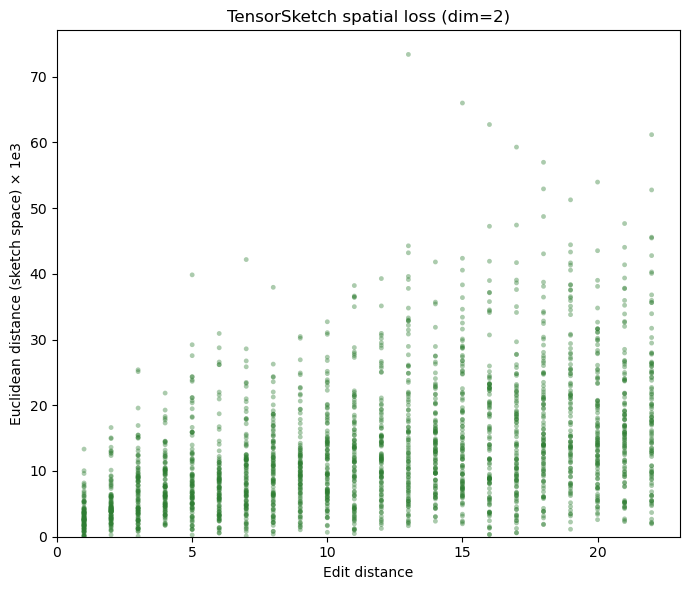

Saved [d=2]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d2.png
  Raw euclidean range: min=0.00004104, max=0.07336260
  Display scale factor: 1000.0


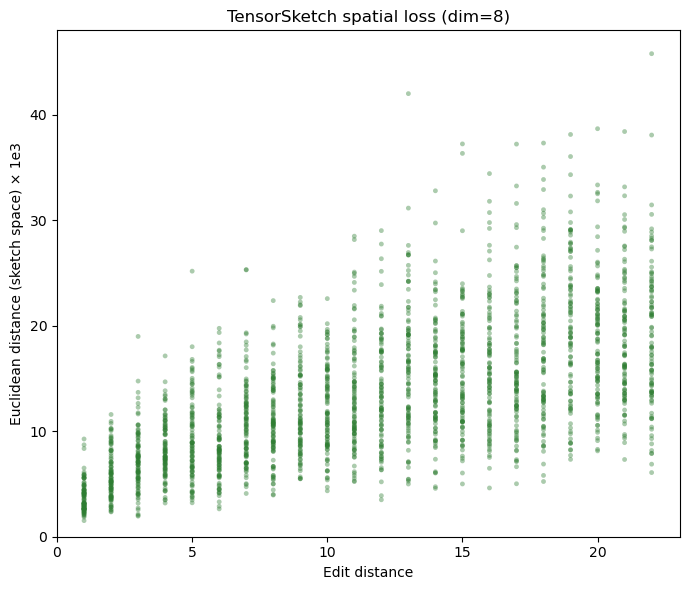

Saved [d=8]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d8.png
  Raw euclidean range: min=0.00152504, max=0.04577010
  Display scale factor: 1000.0


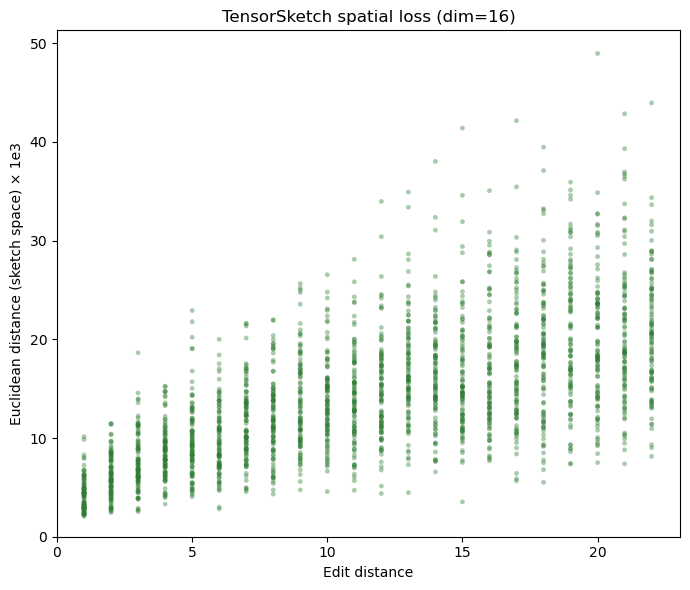

Saved [d=16]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d16.png
  Raw euclidean range: min=0.00205188, max=0.04895500
  Display scale factor: 1000.0


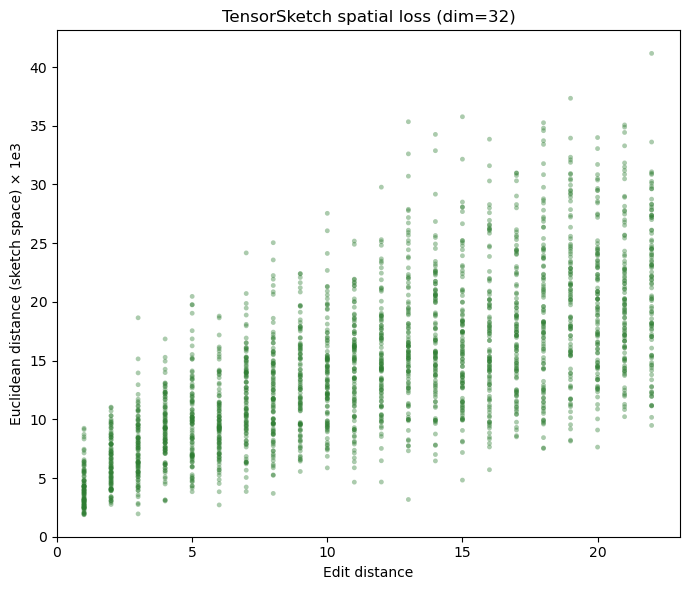

Saved [d=32]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d32.png
  Raw euclidean range: min=0.00187118, max=0.04116330
  Display scale factor: 1000.0


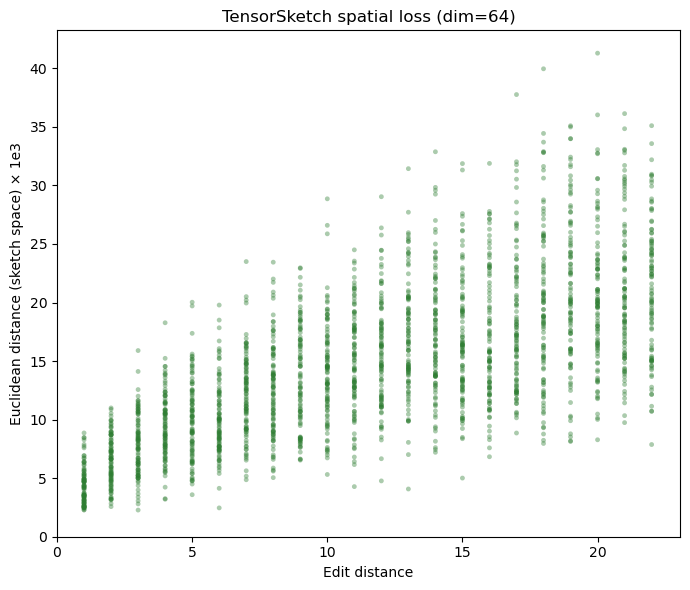

Saved [d=64]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d64.png
  Raw euclidean range: min=0.00227706, max=0.04128980
  Display scale factor: 1000.0


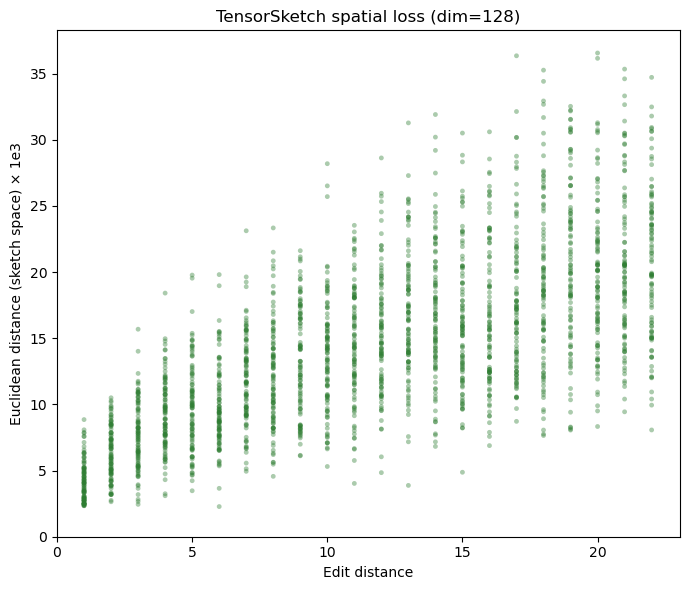

Saved [d=128]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d128.png
  Raw euclidean range: min=0.00227903, max=0.03655390
  Display scale factor: 1000.0


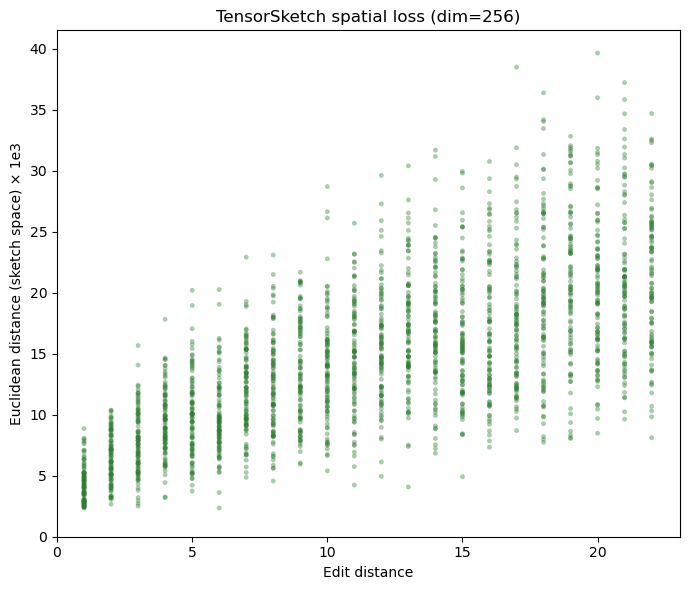

Saved [d=256]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d256.png
  Raw euclidean range: min=0.00235416, max=0.03964220
  Display scale factor: 1000.0


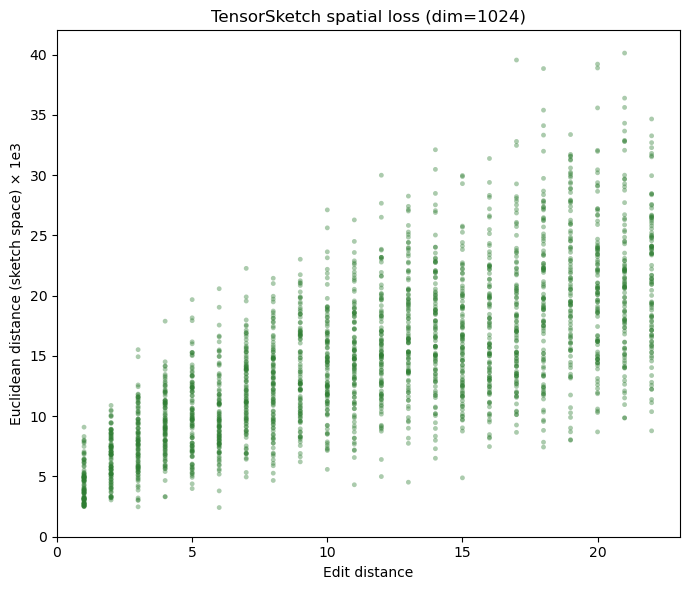

Saved [d=1024]: /home/luting/projects/AnchorMapping/NavigaMer/methods/v5_spatial_loss_output/spatial_loss_scatter_d1024.png
  Raw euclidean range: min=0.00241943, max=0.04012770
  Display scale factor: 1000.0


In [6]:
# Plot one scatter figure per embedding dimension.
for dim in sorted(results_by_dim.keys()):
    edit_dists, euclidean_dists = results_by_dim[dim]

    y_scale = 1.0
    y_unit = 'Euclidean distance (sketch space)'
    if np.nanmax(euclidean_dists) < 0.1:
        y_scale = 1000.0
        y_unit = 'Euclidean distance (sketch space) × 1e3'

    y_plot = euclidean_dists * y_scale

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(edit_dists, y_plot, alpha=0.4, s=12, c='#2e7d32', edgecolors='none')
    ax.set_xlabel('Edit distance')
    ax.set_ylabel(y_unit)
    ax.set_title(f'TensorSketch spatial loss (dim={dim})')
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    plt.tight_layout()

    out_png = OUTPUT_DIR / f"spatial_loss_scatter_d{dim}.png"
    plt.savefig(out_png, dpi=150)
    plt.show()

    print(f"Saved [d={dim}]: {out_png}")
    print(f"  Raw euclidean range: min={np.nanmin(euclidean_dists):.8f}, max={np.nanmax(euclidean_dists):.8f}")
    print(f"  Display scale factor: {y_scale}")